In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer, VGGCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group
from datetime import datetime

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
DATASET = "imagenet-butterfly"

GAMMA = 0.25

In [6]:
dataset = datasets.construct(DATASET)

In [7]:
ds_train = dataset.create_subset(train_split=True)

ds_train, _ = random_split(
    dataset.create_subset(train_split=True),
    [0.1, 0.9]
)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|██████████| 7800/7800 [00:00<00:00, 2081540.45it/s]


We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|██████████| 7800/7800 [00:00<00:00, 2383995.57it/s]


In [9]:
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []
    
    with attributors.make_attributor_for(model, dataset.input_statistics) as attributor:
        print(f"attributor: {attributor}")
        print(f"> composite={attributor.composite}")
        print(f">> canonizers: {attributor.composite.canonizers}")

        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad
                

                output_dimensions = act.shape[1:]
                # print("output.dimension", output_dimensions)
                # todo: check this with Gregoire again!
                ctx = torch.where(
                    act.abs() > 0, 
                    rel / act, 
                    0
                )

                np.testing.assert_allclose(
                    (act * ctx).detach().cpu().numpy(), 
                    (rel * (act.abs() > 0)).detach().cpu().numpy(),
                    atol=1e-6
                )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                if len(act.shape) == 2:
                    act = act[:, :, None, None]
                    ctx = ctx[:, :, None, None]

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx

def get_act_ctx_for_model(
    model,                      
    layer,
    gamma=GAMMA,
    eps=1e-6,
    verbose=False
):

    logit_modifier = attributors.WinningClassOneHotEvidence(num_classes=len(dataset.selected_classes))

    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        gamma=gamma,
        eps=eps,
        verbose=verbose,
    )

In [10]:
def get_spectrum(model_name, arr_layers):

    print(f"Getting {model_name}")
    model = models.get_trained_model(model_name)
    
    utils.modify_last_layer_for_subclasses(
        model,
        dataset.selected_classes
    )

    
    model.to(device)

    
    arr_results = []
    
    for layer in arr_layers:
        arr_act, arr_ctx =  get_act_ctx_for_model(
            model,
            layer,
        )
        n, d = arr_act.shape
        n_samples = n / 20
    
        eigvals_act = np.linalg.eigvalsh(arr_act.T @ arr_act / n_samples).tolist()[::-1]
    
        eigvals_ctx = np.linalg.eigvalsh(arr_ctx.T @ arr_ctx/ n_samples).tolist()[::-1]
    
        eigvals_ccov = np.linalg.eigvalsh(
            (arr_act.T @ arr_ctx +  arr_ctx.T @ arr_act) / n_samples
        )
        eigvals_ccov = sorted(np.abs(eigvals_ccov))[::-1]
        
        arr_results.append(
            (eigvals_act, eigvals_ctx, eigvals_ccov)
        )

    del model
    torch.cuda.empty_cache()
    
    return arr_results

get_spectrum("imagenet-vgg16bn-tv", ["features.33"])

Getting imagenet-vgg16bn-tv
attributor: <zennit.attribution.Gradient object at 0x7f4fa6924d00>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7f4fa6925120>
>> canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7f4fa6925210>]


100%|██████████████████████████████████████████████████████████| 13/13 [00:12<00:00,  1.08it/s]


[([26.217002868652344,
   3.0103421211242676,
   2.390085220336914,
   2.056887149810791,
   1.9555200338363647,
   1.7708545923233032,
   1.6141928434371948,
   1.4893410205841064,
   1.4077681303024292,
   1.3592109680175781,
   1.2672260999679565,
   1.1791976690292358,
   1.1305062770843506,
   1.0365140438079834,
   0.9557700753211975,
   0.9030367732048035,
   0.8786975145339966,
   0.8558634519577026,
   0.8414799571037292,
   0.7870206832885742,
   0.777503252029419,
   0.7554295659065247,
   0.7426928877830505,
   0.7315349578857422,
   0.7201462984085083,
   0.7122328877449036,
   0.6836086511611938,
   0.6701497435569763,
   0.6237830519676208,
   0.6003262996673584,
   0.5949428081512451,
   0.58650141954422,
   0.5649844408035278,
   0.5530593991279602,
   0.5490800142288208,
   0.5237385034561157,
   0.5188166499137878,
   0.5038507580757141,
   0.48951199650764465,
   0.4836016893386841,
   0.46961238980293274,
   0.4637196362018585,
   0.45884183049201965,
   0.45582437

Getting imagenet-vgg16-tv
attributor: <zennit.attribution.Gradient object at 0x7f4fa2259000>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7f4fa2258fa0>
>> canonizers: []


100%|██████████████████████████████████████████████████████████| 13/13 [00:17<00:00,  1.32s/it]


attributor: <zennit.attribution.Gradient object at 0x7f4fa2259300>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7f4fa2259000>
>> canonizers: []


100%|██████████████████████████████████████████████████████████| 13/13 [00:12<00:00,  1.01it/s]


attributor: <zennit.attribution.Gradient object at 0x7f4fa2259270>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7f4fa225b850>
>> canonizers: []


...

100%|██████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.33it/s]


attributor: <zennit.attribution.Gradient object at 0x7f4fa694d5a0>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7f4fa694f2e0>
>> canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7f4fa694e4d0>]


100%|██████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.37it/s]


attributor: <zennit.attribution.Gradient object at 0x7f4fa696d540>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7f4fa696d8a0>
>> canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7f4fa696f130>]


100%|██████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.37it/s]


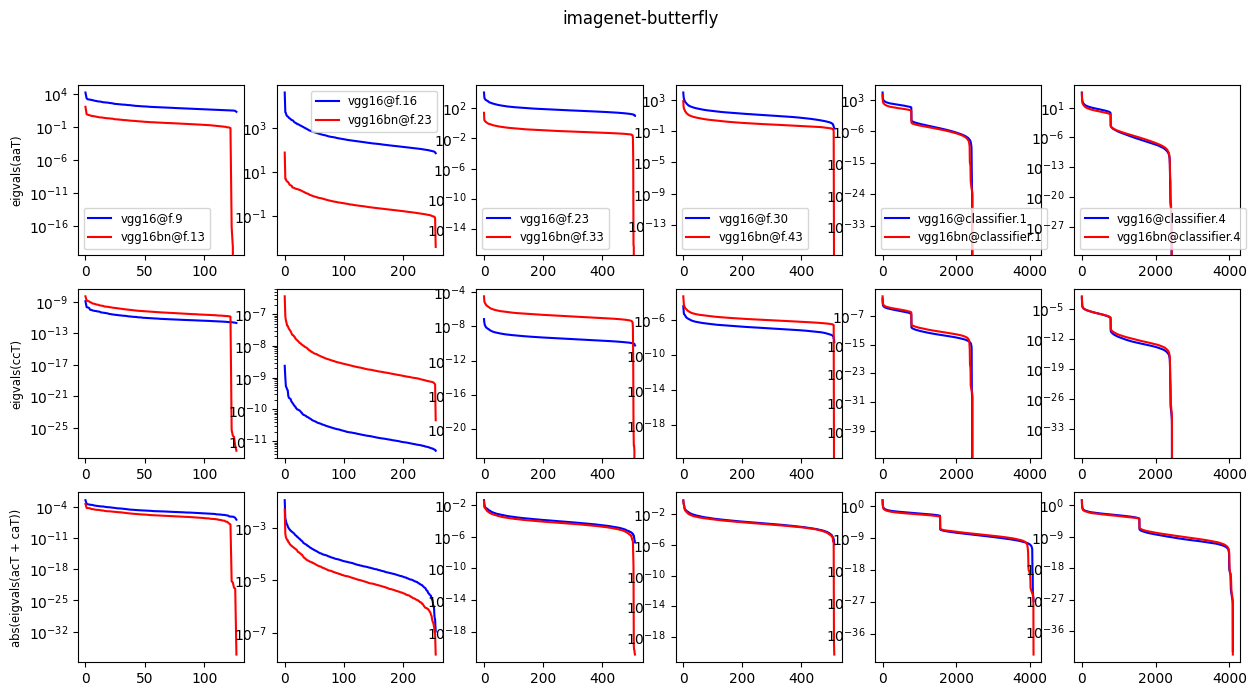

In [11]:
def viz_spectrum_pairs(
    arr_model_layers
):

    assert len(arr_model_layers[0][1]) == len(arr_model_layers[1][1])

    ncols = len(arr_model_layers[0][1])
    nrows = 3
    
    arr_stats = []

    for model_name, arr_layers in arr_model_layers:
        arr_stats.append(
            get_spectrum(model_name, arr_layers)
        )

    arr_row_names = ["eigvals(aaT)", "eigvals(ccT)", "abs(eigvals(acT + caT))"]

    plt.figure(figsize=(2.5*ncols, 2.5*nrows))
    plt.suptitle(f"{dataset}")
    
    for rix in range(nrows):
        for cix in range(ncols):
            plt.subplot(nrows, ncols, rix*ncols + cix+1)
            for _ix, (model_name, arr_layers) in enumerate(arr_model_layers):
                data = arr_stats[_ix][cix][rix]
                color = "b" if _ix == 0 else "r"
                _, name, _ = model_name.split("-")
                layer_name = arr_layers[cix].replace("features", "f")
                plt.plot(data, color=color, label=f"{name}@{layer_name}")

            if cix == 0:
                plt.ylabel(arr_row_names[rix], fontsize="smaller")
        
            plt.yscale("log")

            if rix == 0:
                plt.legend(fontsize="smaller")
    
viz_spectrum_pairs(
    arr_model_layers=[
        ("imagenet-vgg16-tv",   ["features.9", "features.16", "features.23", "features.30", "classifier.1", "classifier.4"]),
        ("imagenet-vgg16bn-tv", ["features.13","features.23", "features.33", "features.43", "classifier.1", "classifier.4"]),
    ]
)

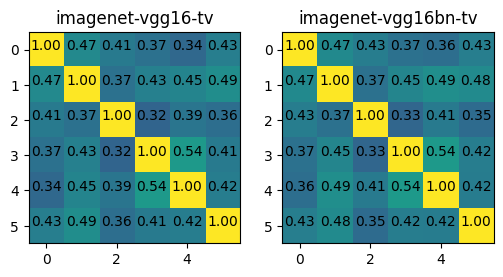

In [29]:
def last_layer_cosine_similarity(arr_model_names):

    ncols = len(arr_model_names)

    plt.figure(figsize=(3*ncols, 3))

    for ix, model_name in enumerate(arr_model_names):
        plt.subplot(1, ncols, ix+1)
        model = models.get_trained_model(model_name)
        
        utils.modify_last_layer_for_subclasses(
            model,
            dataset.selected_classes
        )
    
        weight = model.classifier[-1].weight.detach().numpy()
        unit_weight = weight  / np.linalg.norm(weight, axis=1, keepdims=True)

        cosine = unit_weight @ unit_weight.T
        d, _ = cosine.shape

        plt.title(model_name)
        plt.imshow(np.abs(cosine), vmin=0, vmax=1,)
        for i in range(d):
            for j in range(d):
                plt.text(i, j, f"{cosine[i,j]:.2f}", ha="center")
            
        
last_layer_cosine_similarity(arr_model_names=["imagenet-vgg16-tv", "imagenet-vgg16bn-tv"])

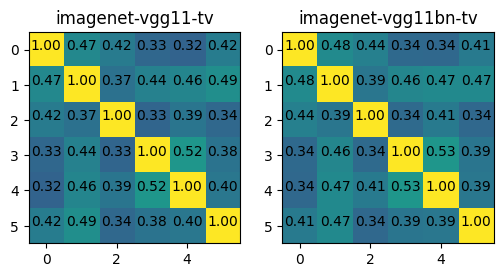

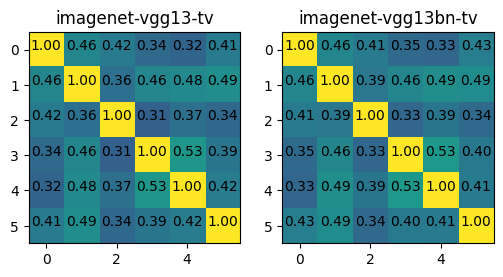

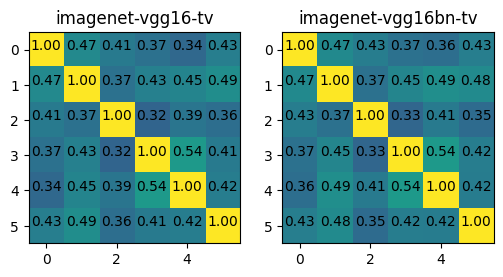

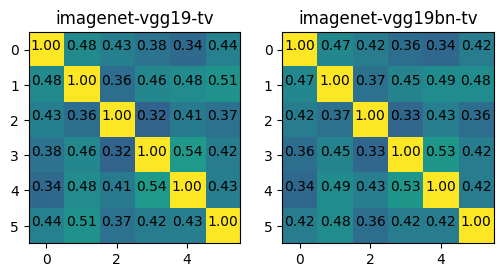

In [31]:
for pair in [
    ("imagenet-vgg11-tv", "imagenet-vgg11bn-tv"),
    ("imagenet-vgg13-tv", "imagenet-vgg13bn-tv"),
    ("imagenet-vgg16-tv", "imagenet-vgg16bn-tv"),
    ("imagenet-vgg19-tv", "imagenet-vgg19bn-tv"),
]:
    last_layer_cosine_similarity(arr_model_names=pair)
    plt.show()

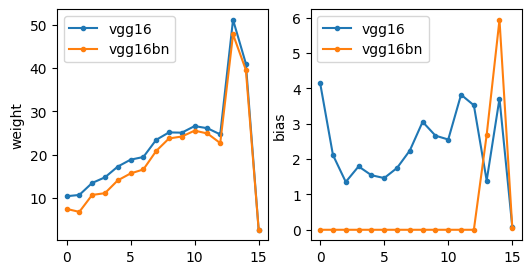

In [58]:
def get_conv_or_linear_layers(model):
    arr_layers = []
    for module in [model.features, model.classifier]:
        for layer in module.children():
            if isinstance(layer, torch.nn.Conv2d) or isinstance(layer, torch.nn.Linear):
                arr_layers.append(layer)

    return arr_layers


def weight_norm(arr_models):
    ncols = 2
    nrows = 1

    plt.figure(figsize=(3*ncols, 3))


    for aix, attr in enumerate(["weight", "bias"]):
        plt.subplot(1, ncols, aix + 1)

        for ix, model_name in enumerate(arr_models):
            model = models.get_trained_model(model_name)        
            utils.modify_last_layer_for_subclasses(
                model,
                dataset.selected_classes
            )
            arr_stats = []
            arr_layers = get_conv_or_linear_layers(model)
            
            for lix, layer in enumerate(arr_layers):
                weight = getattr(layer, attr).detach().numpy()
                norm = np.linalg.norm(weight)
                arr_stats.append(norm)
    
            _, model_name, _ = model_name.split("-")
            plt.plot(arr_stats, marker=".", label=model_name)
        plt.ylabel(attr)
        plt.legend()

weight_norm(
    arr_models=["imagenet-vgg16-tv", "imagenet-vgg16bn-tv"]
)

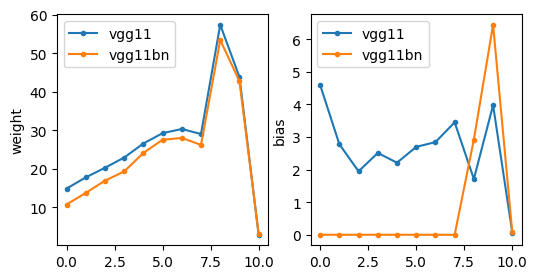

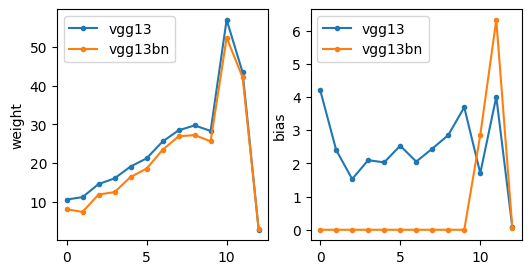

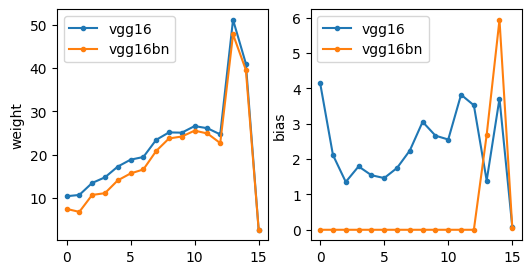

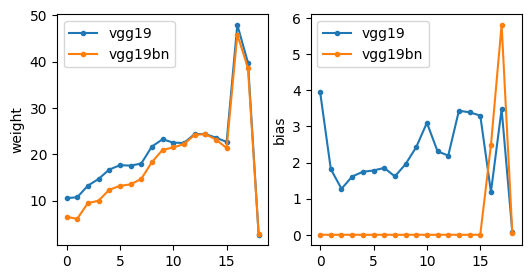

In [60]:
for pair in [
    ("imagenet-vgg11-tv", "imagenet-vgg11bn-tv"),
    ("imagenet-vgg13-tv", "imagenet-vgg13bn-tv"),
    ("imagenet-vgg16-tv", "imagenet-vgg16bn-tv"),
    ("imagenet-vgg19-tv", "imagenet-vgg19bn-tv"),
]:
    weight_norm(arr_models=pair)
    plt.show()

3it [01:02, 20.86s/it]
3it [01:02, 20.68s/it]


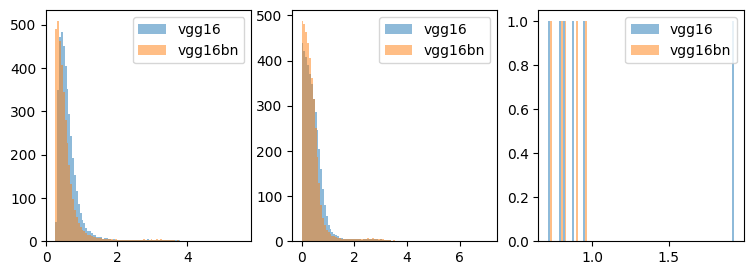

In [13]:
def get_linear_layers(model):
    arr_layers = []
    for module in [model.classifier]:
        for layer in module.children():
            if isinstance(layer, torch.nn.Linear):
                arr_layers.append(layer)

    return arr_layers


def singular_values(arr_models):
    

    arr_basket = []
    for ix, model_name in enumerate(arr_models):
        model = models.get_trained_model(model_name)        
        utils.modify_last_layer_for_subclasses(
                model,
                dataset.selected_classes
        )
        arr_stats = []
        arr_layers = get_linear_layers(model)
            
        for lix, layer in tqdm(enumerate(arr_layers)):
            weight = getattr(layer, "weight").detach().numpy()
            values = np.linalg.svd(weight, compute_uv=False)

            arr_stats.append(values)

        arr_basket.append(arr_stats)

    ncols = len(arr_basket[0])

    plt.figure(figsize=(3*ncols, 3))

    for lix in range(ncols):
        bins = None
        for mix in range(len(arr_models)):
            plt.subplot(1, ncols, lix + 1)
            _, model_name, _ = arr_models[mix].split("-")

            _, bins, _ = plt.hist(arr_basket[mix][lix], bins=100 if bins is None else bins, alpha=0.5, label=model_name)
        plt.legend()

singular_values(
    arr_models=["imagenet-vgg16-tv", "imagenet-vgg16bn-tv"]
)

3it [01:02, 20.67s/it]
3it [01:02, 20.79s/it]


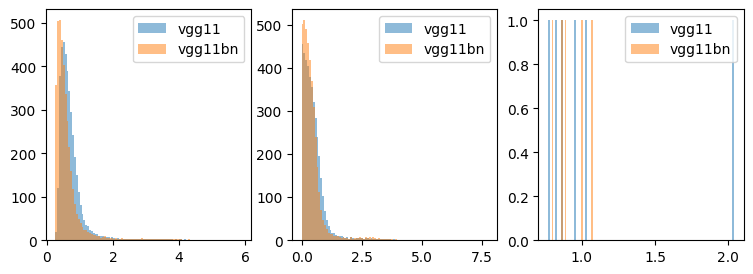

3it [01:02, 20.72s/it]
3it [01:01, 20.60s/it]


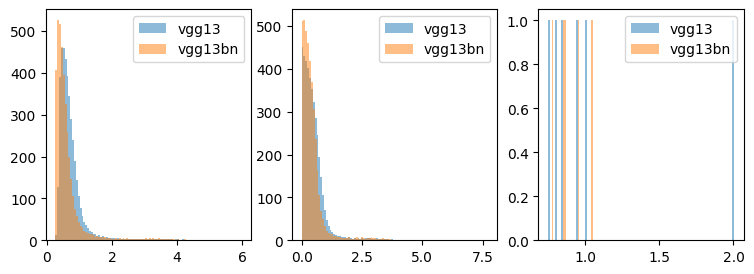

3it [01:02, 20.75s/it]
3it [01:02, 20.67s/it]


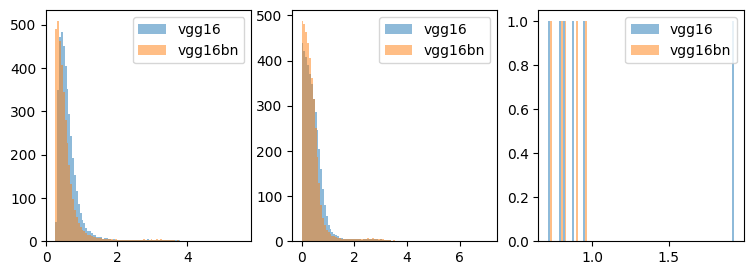

3it [01:02, 20.74s/it]
3it [01:01, 20.55s/it]


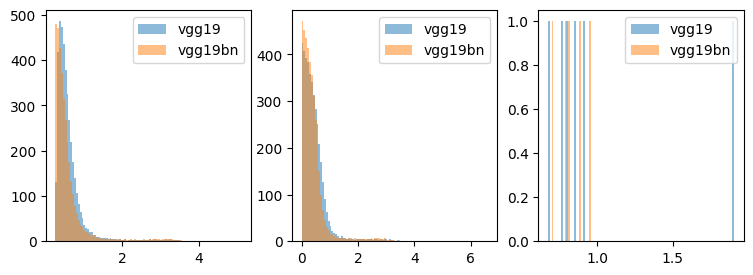

In [14]:
for pair in [
    ("imagenet-vgg11-tv", "imagenet-vgg11bn-tv"),
    ("imagenet-vgg13-tv", "imagenet-vgg13bn-tv"),
    ("imagenet-vgg16-tv", "imagenet-vgg16bn-tv"),
    ("imagenet-vgg19-tv", "imagenet-vgg19bn-tv"),
]:
    singular_values(arr_models=pair)
    plt.show()

In [12]:
print(f"Finished at {datetime.now()}")

Finished at 2024-05-10 08:12:56.424073


# Summary

...
...
...
